In [ ]:
# Install packages
!pip install swig mediapy tqdm
!pip install mujoco==3.1.4
!pip install torch torchrl
!pip install gymnasium[box2d,mujoco]
!pip install opencv-python


zsh:1: no matches found: gymnasium[box2d,mujoco]==0.28.1


# Imports and Functions

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
import torch.nn as nn
import torch.optim as optim
from torchrl.data import TensorDictReplayBuffer
from torchrl.data import LazyMemmapStorage
from tensordict import TensorDict
import mediapy as media
import gymnasium as gym
from tqdm import tqdm


/home/johannes/anaconda3/envs/ml4robotics/lib/python3.11/site-packages/torchrl/data/replay_buffers/samplers.py:34: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


In [ ]:
def render_episode(policy, env):
	frames = []
	score = 0
	state = env.reset()[0]
	terminated = truncated = False
	while not terminated and not truncated:
		frame = env.render()
		if frame is None:
			frame = state
		frames.append(np.asarray(frame, dtype=np.uint8))
		action = policy(state)
		state, reward, terminated, truncated, _ = env.step(action)
		score += reward
	print(f"Finished episode. Cummulative Return: {score}")
	media.show_video(frames, fps=100, loop=True)

In [ ]:
# Env wrapper that restricts CarRacing to 3 driving actions (forward / left / right).
# This is done to speed up convergence.
class ActionRestrictedWrapper(gym.ActionWrapper):
	ENV_ACTIONS = (3, 1, 2)

	def __init__(self, env, min_speed_to_steer=0.02):
		super().__init__(env)
		self.action_space = gym.spaces.Discrete(3)
		self.min_speed_to_steer = min_speed_to_steer

	def action(self, action):
		env_action = self.ENV_ACTIONS[int(action)]
		car = getattr(self.env.unwrapped, 'car', None)
		if car is not None and env_action != 3:
			speed = float(np.linalg.norm(car.hull.linearVelocity))
			if speed < self.min_speed_to_steer:
				return 3
		return env_action

In [ ]:
# Moving average to smooth the episode rewards
def moving_average(x, window=10):
	x_padded = np.pad(x, (window//2, window//2), mode='edge')
	return np.convolve(x_padded, np.ones(window)/window, mode='valid')


In [ ]:
# Global variables
num_episodes = 50
max_steps_per_episode = 1000

# DQN parameters
gamma = 0.99
epsilon = 0.5
epsilon_decay = 0.9999
epsilon_min = 0.01
batch_size = 128
lr = 1e-4
update_target_interval = 1000
replay_buffer_size = 1_000_000

## RL from images
Reinforcement learning from images is a subfield of machine learning that focuses on training agents to make decisions based on visual input. In this approach, the agent directly learns a policy or value function from raw image data, without the need for handcrafted features or explicit state representations. This allows the agent to perceive and understand the environment solely through visual observations.

When it comes to training a reinforcement learning agent from images, there are two main options: using an end-to-end learning algorithm or separating perception and control.

In end-to-end learning, the agent learns to directly map raw image observations to actions. This approach has the advantage of simplicity and can potentially capture complex relationships between images and actions. However, it often requires a large amount of training data and can be computationally expensive.

On the other hand, separating perception and control involves using separate models for perception (e.g., image recognition) and control (e.g., decision-making). The perception model processes the raw images and extracts relevant features, which are then used as input to the control model. This approach can be more interpretable and efficient, as it allows for leveraging existing image recognition techniques and reduces the dimensionality of the problem. However, it requires careful design and engineering of the perception and control modules.

In summary, the choice between end-to-end learning and separating perception and control depends on the specific requirements of the task and the available resources. End-to-end learning offers simplicity but requires more data and computational resources, while separating perception and control provides interpretability and efficiency but requires additional design and engineering efforts.

In [ ]:
## Solution
# Agent that uses a Deep Q-Network to learn to play the CarRacing-v2 environment from images
class DQNAgent:
	def __init__(self, observation_space, action_space):
		self.observation_space = observation_space
		self.action_space = action_space
		self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

		self.q_network = self.build_q_network()
		self.target_network = self.build_q_network()
		self.target_network.load_state_dict(self.q_network.state_dict())

		self.q_optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
		self.q_loss_fn = nn.MSELoss()

		self.batch_size = batch_size
		self.replay_buffer = TensorDictReplayBuffer(batch_size=self.batch_size, storage=LazyMemmapStorage(replay_buffer_size))
		self.gamma = gamma
		self.epsilon = epsilon
		self.epsilon_decay = epsilon_decay
		self.epsilon_min = epsilon_min
		self.update_target_interval = update_target_interval
		self.steps_since_last_target_update = 0

	def build_q_network(self):
		q_network = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),# 3x96x96 -> 16x48x48
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),# 16x48x48 -> 8x24x24
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8*24*24, 64),#8x24x24 -> 64
            nn.ReLU(),
            nn.Linear(64, self.action_space.n)#64 -> action_space.n
		)
		return q_network.to(self.device)

	def act(self, state, explore=False):
		if explore and torch.rand(1) < self.epsilon:
			return self.action_space.sample()
		else:
			with torch.no_grad():
				norm_state = torch.tensor(self.normalize_state(state)).unsqueeze(0).permute(0, 3, 1, 2).to(self.device, torch.float32)
				q_values = self.q_network(norm_state)
				return torch.argmax(q_values, dim=1).to(torch.int64).squeeze().cpu().numpy()

	def store_experience(self, experience: TensorDict):
		self.replay_buffer.add(experience)

	def update(self):
		if len(self.replay_buffer) < self.batch_size:
			return

		batch = self.replay_buffer.sample(self.batch_size)
		states = batch['pixels'].to(self.device)
		actions = batch['action'].to(self.device)
		rewards = batch['reward'].to(self.device)
		next_states = batch['next_pixels'].to(self.device)
		dones = batch['done'].to(self.device)

		norm_states = self.normalize_state(states).to(self.device,torch.float32).permute(0, 3, 1, 2)
		norm_next_states = self.normalize_state(next_states).to(self.device,torch.float32).permute(0, 3, 1, 2)

		q_values = self.q_network(norm_states).gather(1, actions.unsqueeze(1))
		with torch.no_grad():
			next_q_values = self.target_network(norm_next_states).max(1)[0]
		target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

		loss = self.q_loss_fn(q_values, target_q_values.unsqueeze(1))

		self.q_optimizer.zero_grad()
		loss.backward()
		self.q_optimizer.step()

		self.steps_since_last_target_update += 1
		if self.steps_since_last_target_update >= self.update_target_interval:
			self.target_network.load_state_dict(self.q_network.state_dict())
			self.steps_since_last_target_update = 0

		if self.epsilon > self.epsilon_min:
			self.epsilon *= self.epsilon_decay

	def normalize_state(self, state):
		# Normalize the state to [0, 1]
		return state / 255.0


In [ ]:
# Initialize the environment and agent
env = ActionRestrictedWrapper(gym.make('CarRacing-v3', continuous=False))
dqn_agent = DQNAgent(env.observation_space, env.action_space)

# Track episode rewards
episode_rewards_image_dqn = []

# Training loop
for episode in range(num_episodes):
	state = env.reset()[0]
	episode_reward = 0

	pbar = tqdm(range(max_steps_per_episode), leave=True)
	for step in pbar:
		pbar.set_description(f"Episode {episode+1:>3}/{num_episodes} - Reward: {episode_reward:>10.2f}, Epsilon: {dqn_agent.epsilon:<.4f}")
		action = dqn_agent.act(state, explore=True)
		next_state, reward, terminal, truncated, _ = env.step(action)
		tensordict = TensorDict({'pixels': torch.tensor(state).to(torch.float32),
								 'action': torch.tensor(action).to(torch.int64),
								 'reward': torch.tensor(reward).to(torch.float32),
								 'next_pixels': torch.tensor(next_state).to(torch.float32),
								 'done': torch.tensor(terminal or truncated).to(torch.float32)
								 })
		dqn_agent.store_experience(tensordict)
		dqn_agent.update()
		state = next_state
		episode_reward += float(reward)
		if terminal or truncated:
			break
	episode_rewards_image_dqn.append(episode_reward)



Episode   1/50 - Reward:      13.68, Epsilon: 0.4679:  79%|███████▉  | 791/1000 [00:08<00:02, 88.44it/s] 
Episode   2/50 - Reward:      48.04, Epsilon: 0.4371:  68%|██████▊   | 679/1000 [00:08<00:04, 77.33it/s]
Episode   3/50 - Reward:      33.35, Epsilon: 0.4025:  82%|████████▏ | 823/1000 [00:10<00:02, 77.50it/s]
Episode   4/50 - Reward:      65.57, Epsilon: 0.3642: 100%|█████████▉| 999/1000 [00:13<00:00, 74.95it/s]
Episode   5/50 - Reward:     -50.43, Epsilon: 0.3296: 100%|█████████▉| 999/1000 [00:12<00:00, 76.89it/s]
Episode   6/50 - Reward:      -8.26, Epsilon: 0.3161:  42%|████▏     | 417/1000 [00:05<00:07, 75.64it/s]
Episode   7/50 - Reward:      16.56, Epsilon: 0.2967:  63%|██████▎   | 633/1000 [00:08<00:04, 74.31it/s]
Episode   8/50 - Reward:      62.18, Epsilon: 0.2775:  66%|██████▋   | 665/1000 [00:08<00:04, 75.62it/s]
Episode   9/50 - Reward:     -55.63, Epsilon: 0.2530:  92%|█████████▏| 923/1000 [00:12<00:01, 75.56it/s]
Episode  10/50 - Reward:      16.54, Epsilon: 0.2290: 

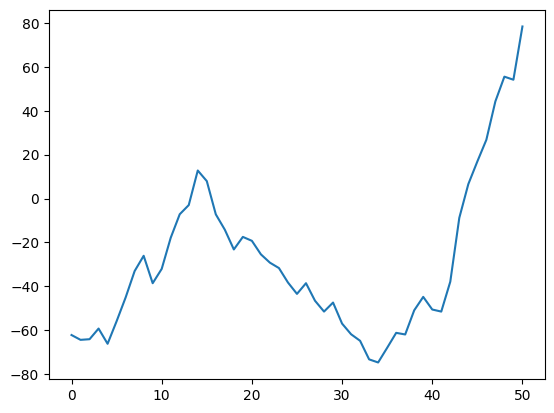

In [ ]:
# Smoothed episode rewards
smoothed_episode_rewards_image_dqn = moving_average(episode_rewards_image_dqn)

# Plot smoothed episode rewards
plt.plot(smoothed_episode_rewards_image_dqn)
plt.show()


In [ ]:
# Render an episode using the trained agent
render_env = ActionRestrictedWrapper(gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array'))
render_episode(dqn_agent.act, render_env)
render_env.close()

Finished episode. Cummulative Return: 10.266159695817127


This browser does not support the video tag.


### Tasks:
1. Code the Network for the DQN Agent.


## VAE Latent Space

Instead of learning directly from raw pixels, we **separate perception from control**: a VAE maps each image to a low-dimensional latent vector, and DQN learns a policy on that latent state.

The encoder is trained to compress the image while preserving enough information to reconstruct it. For RL, we use the latent mean as the state — a compact representation that drops irrelevant pixel detail and lets a small MLP focus on decision-making rather than visual feature extraction.

In [ ]:
# Define the VAE model.
class VAE(nn.Module):
	def __init__(self, latent_dim, input_shape=(1, 28, 28)):
		super(VAE, self).__init__()
		flatten_dim = 8 * input_shape[1]//4 * input_shape[2]//4

		self.encoder = nn.Sequential(
            nn.Conv2d(input_shape[0], 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(flatten_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2*latent_dim)
        )

		self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, flatten_dim),
            nn.ReLU(),
            nn.Unflatten(1, (8, input_shape[1] // 4, input_shape[2] // 4)),
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, input_shape[0], kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

	def encode(self, x):
		h = self.encoder(x)
		mu, log_var = torch.chunk(h, 2, dim=1)
		return mu, log_var

	def reparameterize(self, mu, log_var):
		std = torch.exp(0.5 * log_var)
		eps = torch.randn_like(std)
		z = mu + eps * std
		return z

	def decode(self, z):
		return self.decoder(z)

	def forward(self, x):
		mu, log_var = self.encode(x)
		z = self.reparameterize(mu, log_var)
		x_hat = self.decode(z)
		return x_hat, mu, log_var

# Define the loss function.
def vae_loss(x, x_hat, mu, log_var):
	reconstruction_loss = nn.BCELoss(reduction='sum')(x_hat, x)
	kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
	return reconstruction_loss + kl_divergence



In [ ]:
## Solution
LATENT_DIM = 8
UPDATE_VAE_INTERVAL = 1
UPDATE_VAE_BATCHES = 1


class VAEDQNAgent(DQNAgent):
	def __init__(self, observation_space, action_space):
		super(VAEDQNAgent, self).__init__(observation_space, action_space)
		self.vae = self.build_vae()
		self.vae_loss_fn = vae_loss
		self.vae_optimizer = optim.Adam(self.vae.parameters(), lr=lr)
		self.update_vae_interval = UPDATE_VAE_INTERVAL
		self.update_vae_batches = UPDATE_VAE_BATCHES
		self.steps_since_last_vae_update = 0

	def build_vae(self):
		return VAE(LATENT_DIM, input_shape=(3, 96, 96)).to(self.device)

	def build_q_network(self):
		q_network = nn.Sequential(
			nn.Linear(LATENT_DIM, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU(),
			nn.Linear(128, self.action_space.n)
		)
		return q_network.to(self.device)

	def update(self):
		if self.steps_since_last_vae_update >= self.update_vae_interval:
			self.steps_since_last_vae_update = 0
			for _ in range(self.update_vae_batches):
				self.update_vae()
		else:
			self.steps_since_last_vae_update += 1
		self.update_dqn()

	def update_vae(self):
		if len(self.replay_buffer) < self.batch_size:
			return

		batch = self.replay_buffer.sample(self.batch_size)
		states = batch['pixels'].to(self.device)
		states_norm = self.normalize_state(states).to(self.device).to(torch.float32).permute(0, 3, 1, 2)

		# Encode states using VAE
		mu, log_var = self.vae.encode(states_norm)
		z = self.vae.reparameterize(mu, log_var)

		reconstructed_states = self.vae.decode(z)

		loss = self.vae_loss_fn(states_norm, reconstructed_states, mu, log_var)

		self.vae_optimizer.zero_grad()
		loss.backward()
		self.vae_optimizer.step()

	def update_dqn(self):
		if len(self.replay_buffer) < self.batch_size:
			return

		batch = self.replay_buffer.sample(self.batch_size)
		states = batch['pixels'].to(self.device)
		actions = batch['action'].to(self.device)
		rewards = batch['reward'].to(self.device)
		next_states = batch['next_pixels'].to(self.device)
		dones = batch['done'].to(self.device)

		states_norm = self.normalize_state(states).to(self.device).to(torch.float32).permute(0, 3, 1, 2)
		next_states_norm = self.normalize_state(next_states).to(self.device).to(torch.float32).permute(0, 3, 1, 2)

		# Encode states and next_states using VAE
		with torch.no_grad():
			latent_states = self.vae.encode(states_norm)[0]
			latent_next_states = self.vae.encode(next_states_norm)[0]

		q_values = self.q_network(latent_states).gather(1, actions.unsqueeze(1))
		next_q_values = self.target_network(latent_next_states).max(1)[0].detach()
		target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

		loss = self.q_loss_fn(q_values, target_q_values.unsqueeze(1))

		self.q_optimizer.zero_grad()
		loss.backward()
		self.q_optimizer.step()

		self.steps_since_last_target_update += 1
		if self.steps_since_last_target_update >= self.update_target_interval:
			self.target_network.load_state_dict(self.q_network.state_dict())
			self.steps_since_last_target_update = 0

		if self.epsilon > self.epsilon_min:
			self.epsilon *= self.epsilon_decay

	def act(self, state, explore=False):
		if explore and torch.rand(1) < self.epsilon:
			return self.action_space.sample()
		else:
			with torch.no_grad():
				state_norm = torch.tensor(self.normalize_state(state)).unsqueeze(0).permute(0, 3, 1, 2).to(self.device, torch.float32)
				latent_vector = self.vae.encode(state_norm)[0]
				q_values = self.q_network(latent_vector)
				return torch.argmax(q_values, dim=1).squeeze().cpu().numpy()


In [ ]:
# Initialize the environment and agent
env = ActionRestrictedWrapper(gym.make('CarRacing-v3', continuous=False))
vae_dqn_agent = VAEDQNAgent(env.observation_space, env.action_space)

# Track episode rewards
episode_rewards_vae_dqn = []

# Training loop
for episode in range(num_episodes):
	state = env.reset()[0]
	episode_reward = 0

	pbar = tqdm(range(max_steps_per_episode), leave=True)
	for step in pbar:
		pbar.set_description(f"Episode {episode+1:>3}/{num_episodes} - Reward: {episode_reward:>10.2f}, Epsilon: {vae_dqn_agent.epsilon:<.4f}")
		# Choose an action based on the current state
		action = vae_dqn_agent.act(state, explore=True)

		# Take the chosen action in the environment
		next_state, reward, terminal, truncated, _ = env.step(action)

		# Store the experience in the agent's replay buffer
		tensordict = TensorDict({'pixels': torch.tensor(state).to(torch.float32),
								 'action': torch.tensor(action).to(torch.int64),
								 'reward': torch.tensor(reward).to(torch.float32),
								 'next_pixels': torch.tensor(next_state).to(torch.float32),
								 'done': torch.tensor(terminal or truncated).to(torch.float32)
								 })
		vae_dqn_agent.store_experience(tensordict)

		# Update the agent's Q-network
		vae_dqn_agent.update()

		# Update the current state and episode reward
		state = next_state
		episode_reward += float(reward)

		if terminal or truncated:
			break

	episode_rewards_vae_dqn.append(episode_reward)


Episode   1/50 - Reward:     -16.23, Epsilon: 0.4766:  61%|██████    | 606/1000 [00:07<00:05, 76.50it/s] 
Episode   2/50 - Reward:     -49.73, Epsilon: 0.4313: 100%|█████████▉| 999/1000 [00:15<00:00, 64.54it/s]
Episode   3/50 - Reward:     -46.02, Epsilon: 0.3949:  88%|████████▊ | 880/1000 [00:13<00:01, 64.34it/s]
Episode   4/50 - Reward:       8.80, Epsilon: 0.3573: 100%|█████████▉| 999/1000 [00:17<00:00, 56.26it/s]
Episode   5/50 - Reward:      46.28, Epsilon: 0.3233: 100%|█████████▉| 999/1000 [00:21<00:00, 46.12it/s]
Episode   6/50 - Reward:      36.94, Epsilon: 0.2925: 100%|█████████▉| 999/1000 [00:20<00:00, 48.42it/s]
Episode   7/50 - Reward:      -1.00, Epsilon: 0.2647: 100%|█████████▉| 999/1000 [00:20<00:00, 49.81it/s]
Episode   8/50 - Reward:     -60.29, Epsilon: 0.2433:  84%|████████▍ | 841/1000 [00:17<00:03, 47.80it/s]
Episode   9/50 - Reward:     -45.29, Epsilon: 0.2202: 100%|█████████▉| 999/1000 [00:20<00:00, 48.00it/s]
Episode  10/50 - Reward:      37.63, Epsilon: 0.2048: 

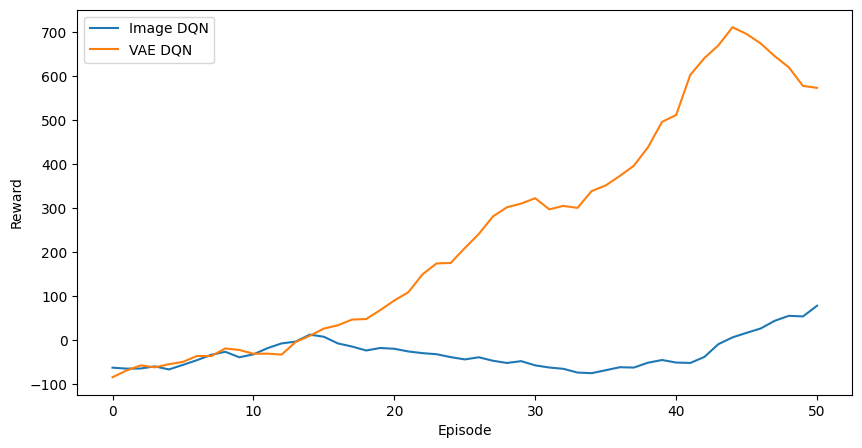

In [ ]:
## Solution
# Plot the moving average of the episode rewards for both agents.
plt.figure(figsize=(10, 5))
plt.plot(moving_average(episode_rewards_image_dqn), label='Image DQN')
plt.plot(moving_average(episode_rewards_vae_dqn), label='VAE DQN')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.show()

In [ ]:
# Run one episode and collect frames, latent states, and reconstructions
max_steps = max_steps_per_episode
frames = np.empty((max_steps, 400,600,3), dtype=np.uint8)
latents = np.empty((max_steps, vae_dqn_agent.vae.encoder[-1].out_features // 2), dtype=np.float32)
recons = np.empty((max_steps, 96,96,3), dtype=np.uint8)

render_env = ActionRestrictedWrapper(gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array'))
state = render_env.reset()[0]
reward_sum = 0.
done = False
step = 0
while not done and step < max_steps:
	frames[step] = render_env.render()
	state_norm = torch.tensor(vae_dqn_agent.normalize_state(state)).unsqueeze(0).permute(0, 3, 1, 2).to(vae_dqn_agent.device, torch.float32)
	with torch.no_grad():
		mu, _ = vae_dqn_agent.vae.encode(state_norm)
		latent = mu.cpu().numpy().squeeze()
		latents[step] = latent
		recon = vae_dqn_agent.vae.decode(mu).cpu().numpy().squeeze().transpose(1, 2, 0)
		recon = np.clip(recon * 255, 0, 255).astype(np.uint8)
		recons[step] = recon
	action = vae_dqn_agent.act(state)
	state, reward, done, truncated, _ = render_env.step(action)
	reward_sum += float(reward)
	done = done or truncated
	step += 1

frames = frames[:step]
latents = latents[:step]
recons = recons[:step]

# Print the total reward for the episode
print(f"Total reward for the episode: {reward_sum}")

# Stack environment, reconstruction, and latent visualization frames
video_frames = []
for i in range(len(frames)):
	fig, axes = plt.subplots(1, 3, figsize=(12, 4))
	axes[0].imshow(frames[i])
	axes[0].set_title("Environment")
	axes[0].axis('off')
	axes[1].imshow(recons[i])
	axes[1].set_title("VAE Reconstruction")
	axes[1].axis('off')
	if latents.shape[1] == 2:
		axes[2].scatter(latents[:,0], latents[:,1], c='gray', alpha=0.3)
		axes[2].scatter(latents[i,0], latents[i,1], c='red')
		axes[2].set_xlim(latents[:,0].min()-1, latents[:,0].max()+1)
		axes[2].set_ylim(latents[:,1].min()-1, latents[:,1].max()+1)
		axes[2].set_title("Latent State (2D)")
	else:
		axes[2].bar(np.arange(latents.shape[1]), latents[i])
		axes[2].set_ylim(latents.min(), latents.max())
		axes[2].set_title("Latent State")
	plt.tight_layout()
	fig.canvas.draw()
	# Convert to numpy array
	img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
	img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))[..., :3]  # Drop alpha channel
	video_frames.append(img)
	plt.close(fig)
media.show_video(video_frames, fps=100, loop=False)


Total reward for the episode: 908.599999999984


This browser does not support the video tag.


## Tasks:
1. Finalize the VAE-DQN agent and train it. Does it converge faster than the E2E agent?
2. Play around with the latent space of the VAE. Are there relevant directions in the latent space that correspond to specific actions or behaviors in the environment?
3. What problems do you see when using a VAE to transform the high dimensional image input to a low dimensional latent state and using DQN to learn from this latent state? How can you address these issues?

# Perception-Based State

Like the VAE approach, we again **separate perception from control**: a perception module maps each image to a low-dimensional state, and DQN learns a policy on that state instead of raw pixels.

The difference is that we no longer *learn* this representation. We build a **perception pipeline from first principles**, using domain knowledge about what matters for driving: cast rays from the car to measure distances to the track boundary, and read speed, steering, and gyro from the HUD. The result is a compact, interpretable state vector that a small MLP can learn from quickly.

In [ ]:
## Solution
NUM_FORWARD_RAYS = 6
NUM_SIDE_RAYS = 2
RAY_FOV = 1.4
STATE_DIM = NUM_FORWARD_RAYS + NUM_SIDE_RAYS + 3  # rays + speed, steering, gyro


def _is_grass(pixel):
	h, s, v = cv2.cvtColor(pixel.reshape(1, 1, 3).astype(np.uint8), cv2.COLOR_RGB2HSV)[0, 0]
	return 35 <= h <= 90 and s >= 35 and v >= 30


def _is_car(pixel):
	r, g, b = int(pixel[0]), int(pixel[1]), int(pixel[2])
	return r > 120 and r > g + 40 and r > b + 40


def _car_center(track):
	"""Find the car blob nearest the bottom-center of the track view."""
	h, w = track.shape[:2]
	rgb = track.astype(np.int16)
	r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
	car = ((r > 120) & (r > g + 40) & (r > b + 40)).astype(np.uint8)
	n, _, stats, centroids = cv2.connectedComponentsWithStats(car, connectivity=8)
	if n <= 1:
		return w // 2, h - max(5, h // 12)
	target = np.array([w / 2, h - max(5, h // 12)])
	best, best_dist = None, float('inf')
	for i in range(1, n):
		if stats[i, cv2.CC_STAT_AREA] < 8:
			continue
		cx, cy = centroids[i]
		dist = float(np.linalg.norm(np.array([cx, cy]) - target))
		if dist < best_dist:
			best_dist, best = dist, (int(round(cx)), int(round(cy)))
	return best if best is not None else (w // 2, h - max(5, h // 12))


def _cast_ray(track, cx, cy, angle):
	th, tw = track.shape[:2]
	dx, dy = np.sin(angle), -np.cos(angle)
	for step in range(1, th):
		x, y = int(cx + step * dx), int(cy + step * dy)
		if x < 0 or x >= tw or y < 0 or y >= th:
			return step / th, (x, y)
		px = track[y, x]
		if _is_car(px):
			continue
		if _is_grass(px):
			return step / th, (x, y)
	return 1.0, (int(cx + th * dx), int(cy + th * dy))


def _hud_layout(h, w):
	slot, bar = w / 40.0, h / 40.0
	y_hud = int(round(h - 5 * bar))
	y_bar_top = int(round(h - 4 * bar))
	y_bar_bot = int(round(h - 2 * bar))
	return {
		'y_hud': y_hud,
		'hud_rows': h - y_hud,
		'speed': (round(5 * slot), y_hud, round(6 * slot), h - 1),
		'steering': (round(20 * slot), y_bar_top, round(30 * slot), y_bar_bot),
		'gyro': (round(30 * slot), y_bar_top, min(w - 1, round(40 * slot)), y_bar_bot),
	}


def _hud_masks(image, layout):
	h, w = image.shape[:2]
	masks = {}
	sx1, sy1, sx2, sy2 = layout['speed']
	stx1, sty1, stx2, sty2 = layout['steering']
	gx1, gy1, gx2, gy2 = layout['gyro']

	speed = np.zeros((h, w), dtype=bool)
	speed[sy1:sy2 + 1, sx1:sx2 + 1] = image[sy1:sy2 + 1, sx1:sx2 + 1].min(axis=2) >= 140
	masks['speed'] = speed

	steer = np.zeros((h, w), dtype=bool)
	roi = image[sty1:sty2 + 1, stx1:stx2 + 1]
	green = roi[:, :, 1].astype(np.int16) - np.maximum(roi[:, :, 0], roi[:, :, 2]).astype(np.int16)
	steer[sty1:sty2 + 1, stx1:stx2 + 1] = green > 30
	masks['steering'] = steer

	gyro = np.zeros((h, w), dtype=bool)
	roi = image[gy1:gy2 + 1, gx1:gx2 + 1]
	red = roi[:, :, 0].astype(np.int16) - np.maximum(roi[:, :, 1], roi[:, :, 2]).astype(np.int16)
	gyro[gy1:gy2 + 1, gx1:gx2 + 1] = red > 30
	masks['gyro'] = gyro
	return masks


def _set_pixel(img, x, y, color):
	h, w = img.shape[:2]
	if 0 <= x < w and 0 <= y < h:
		img[y, x] = color


def _draw_line(img, x0, y0, x1, y1, color):
	x0, y0, x1, y1 = int(x0), int(y0), int(x1), int(y1)
	dx, dy = abs(x1 - x0), abs(y1 - y0)
	x, y = x0, y0
	sx = 1 if x0 <= x1 else -1
	sy = 1 if y0 <= y1 else -1
	err = dx - dy
	while True:
		_set_pixel(img, x, y, color)
		if x == x1 and y == y1:
			break
		e2 = 2 * err
		if e2 > -dy:
			err -= dy
			x += sx
		if e2 < dx:
			err += dx
			y += sy


def _border_mask(img, mask, color):
	h, w = mask.shape
	for y in range(h):
		for x in range(w):
			if not mask[y, x]:
				continue
			for dy, dx in ((0, 1), (0, -1), (1, 0), (-1, 0)):
				ny, nx = y + dy, x + dx
				if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
					img[ny, nx] = color


def encode_perception(image):
	if isinstance(image, torch.Tensor):
		image = image.cpu().numpy()
	image = np.clip(image, 0, 255).astype(np.uint8)

	h, w = image.shape[:2]
	layout = _hud_layout(h, w)
	track = image[:layout['y_hud']]
	cx, cy = _car_center(track)

	rays, endpoints = [], []
	for angle in np.linspace(-RAY_FOV / 2, RAY_FOV / 2, NUM_FORWARD_RAYS):
		d, end = _cast_ray(track, cx, cy, angle)
		rays.append(d)
		endpoints.append(end)
	for angle in (-np.pi / 2, np.pi / 2):
		d, end = _cast_ray(track, cx, cy, angle)
		rays.append(d)
		endpoints.append(end)

	masks = _hud_masks(image, layout)
	speed = float(masks['speed'].any(axis=1).sum()) / max(1, layout['hud_rows'])
	if masks['steering'].any():
		xs = np.where(masks['steering'].any(axis=0))[0]
		steering = float(xs.mean() / max(1, w - 1) - 0.5) * 2
	else:
		steering = 0.0
	gyro = float(masks['gyro'].any(axis=1).sum()) / max(1, layout['hud_rows'])

	state = np.array(rays + [speed, np.clip(steering, -1, 1), gyro], dtype=np.float32)
	return state, {
		'track': track, 'ego': (cx, cy), 'endpoints': endpoints,
		'hud_masks': masks, 'hud_rois': layout,
	}


def render_perception_overlay(image, show_rays=True):
	"""Render the perception overlay."""
	if isinstance(image, torch.Tensor):
		image = image.cpu().numpy()
	vis = np.clip(image, 0, 255).astype(np.uint8).copy()
	_, dbg = encode_perception(image)

	if show_rays:
		cx, cy = dbg['ego']
		for x, y in dbg['endpoints']:
			_draw_line(vis, cx, cy, x, y, (255, 0, 255))
			_set_pixel(vis, x, y, (255, 255, 0))
		_set_pixel(vis, cx, cy, (0, 255, 255))

	for name, color in (('speed', (0, 255, 255)), ('steering', (255, 255, 0)), ('gyro', (255, 255, 0))):
		mask = dbg['hud_masks'][name]
		if mask.any():
			_border_mask(vis, mask, color)
	return vis


class CarRacingStateEncoder:
	def __init__(self, device=None):
		self.state_dim = STATE_DIM
		self.device = device or torch.device('cpu')

	def encode(self, image, return_debug=False):
		state, dbg = encode_perception(image)
		t = torch.tensor(state, dtype=torch.float32, device=self.device)
		return (t, dbg) if return_debug else t

	def render_debug(self, image, show_rays=True):
		return render_perception_overlay(image, show_rays=show_rays)



In [ ]:
# DQN agent that encodes pixel observations via CarRacingStateEncoder
class PerceptionDQNAgent:
	"""Small MLP DQN on handcrafted state features."""

	def __init__(self, observation_space, action_space):
		self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
		self.encoder = CarRacingStateEncoder(device=self.device)
		self.state_dim = self.encoder.state_dim
		self.observation_space = observation_space
		self.action_space = action_space
		self.q_network = self._net().to(self.device)
		self.target_network = self._net().to(self.device)
		self.target_network.load_state_dict(self.q_network.state_dict())
		self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
		self.loss_fn = nn.MSELoss()
		self.batch_size = batch_size
		self.buffer = TensorDictReplayBuffer(batch_size=self.batch_size, storage=LazyMemmapStorage(replay_buffer_size))
		self.gamma = gamma
		self.epsilon = epsilon
		self.epsilon_decay = epsilon_decay
		self.epsilon_min = epsilon_min
		self.update_target_interval = update_target_interval
		self.steps_since_last_target_update = 0

	def _net(self):
		return nn.Sequential(
			nn.LayerNorm(self.state_dim),
			nn.Linear(self.state_dim, 64), nn.ReLU(),
			nn.Linear(64, self.action_space.n),
		)

	def _features(self, pixels):
		if isinstance(pixels, torch.Tensor):
			pixels = pixels.cpu().numpy()
		if pixels.ndim == 4:
			return torch.stack([self.encoder.encode(f) for f in pixels])
		return self.encoder.encode(pixels)

	def act(self, state, explore=False):
		if explore and torch.rand(1) < self.epsilon:
			return self.action_space.sample()
		with torch.no_grad():
			q = self.q_network(self._features(state).unsqueeze(0))
			return int(torch.argmax(q, dim=1).item())

	def store_experience(self, td):
		td = td.clone()
		td['state_features'] = self._features(td['pixels']).cpu()
		td['next_state_features'] = self._features(td['next_pixels']).cpu()
		self.buffer.add(td)

	def update(self):
		if len(self.buffer) < self.batch_size:
			return
		b = self.buffer.sample(self.batch_size)
		s, ns = b['state_features'].float().to(self.device), b['next_state_features'].float().to(self.device)
		a = b['action'].long().to(self.device)
		r = b['reward'].to(self.device)
		d = b['done'].to(self.device)
		q = self.q_network(s).gather(1, a.unsqueeze(1))
		with torch.no_grad():
			tgt = r + self.gamma * self.target_network(ns).max(1)[0] * (1 - d)
		loss = self.loss_fn(q, tgt.unsqueeze(1))
		self.optimizer.zero_grad()
		loss.backward()
		self.optimizer.step()
		self.steps_since_last_target_update += 1
		if self.steps_since_last_target_update >= self.update_target_interval:
			self.target_network.load_state_dict(self.q_network.state_dict())
			self.steps_since_last_target_update = 0
		if self.epsilon > self.epsilon_min:
			self.epsilon *= self.epsilon_decay


state (96x96 obs): [0.12 0.18 0.43 0.86 0.44 0.26 0.1  0.15 0.17 0.   0.5 ]


environment | overlay

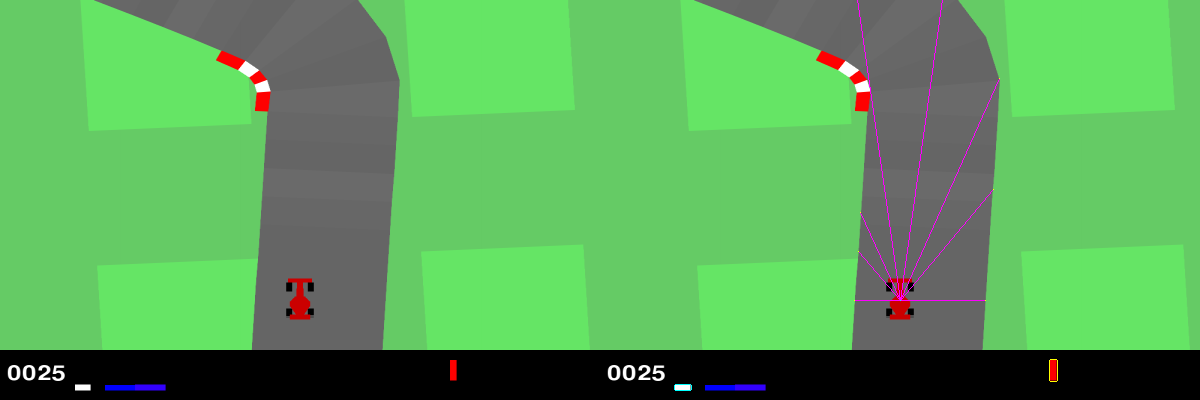

In [ ]:
## Solution
# Visualize handcrafted state features
demo_env = ActionRestrictedWrapper(gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array'))
encoder = CarRacingStateEncoder()
frame_obs = demo_env.reset()[0]
for _ in range(100):
    action = np.random.choice(demo_env.action_space.n, p=[0.55, 0.225, 0.225])
    frame_obs, _, term, trunc, _ = demo_env.step(action)
    if term or trunc:
        break
frame_vis = demo_env.render()
state = encoder.encode(frame_obs)  # agent trains on the 96x96 observation
overlay = encoder.render_debug(frame_vis)  # overlay at native render resolution
demo_env.close()

print('state (96x96 obs):', np.round(state.cpu().numpy(), 2))

h, w = frame_vis.shape[:2]
panel = np.concatenate([frame_vis, overlay], axis=1)
media.show_image(panel, height=h, downsample=False, pixelated=False, title='environment | overlay')



In [ ]:
# Train perception DQN
env = ActionRestrictedWrapper(gym.make('CarRacing-v3', continuous=False))
perception_dqn_agent = PerceptionDQNAgent(env.observation_space, env.action_space)
episode_rewards_perception_dqn = []

for episode in range(num_episodes):
	state = env.reset()[0]
	episode_reward = 0

	pbar = tqdm(range(max_steps_per_episode), leave=True)
	for step in pbar:
		pbar.set_description(
			f"Episode {episode + 1:>3}/{num_episodes} - "
			f"Reward: {episode_reward:>10.2f}, Epsilon: {perception_dqn_agent.epsilon:<.4f}"
		)
		action = perception_dqn_agent.act(state, explore=True)
		next_state, reward, terminal, truncated, _ = env.step(action)
		perception_dqn_agent.store_experience(TensorDict({
			'pixels': torch.tensor(state, dtype=torch.float32),
			'action': torch.tensor(action, dtype=torch.int64),
			'reward': torch.tensor(reward, dtype=torch.float32),
			'next_pixels': torch.tensor(next_state, dtype=torch.float32),
			'done': torch.tensor(float(terminal or truncated)),
		}))
		perception_dqn_agent.update()
		state, episode_reward = next_state, episode_reward + float(reward)
		if terminal or truncated:
			break
	episode_rewards_perception_dqn.append(episode_reward)



Episode   1/50 - Reward:       1.55, Epsilon: 0.4582: 100%|█████████▉| 999/1000 [00:10<00:00, 98.02it/s] 
Episode   2/50 - Reward:       4.58, Epsilon: 0.4146: 100%|█████████▉| 999/1000 [00:10<00:00, 94.96it/s] 
Episode   3/50 - Reward:       1.08, Epsilon: 0.3752: 100%|█████████▉| 999/1000 [00:10<00:00, 98.86it/s] 
Episode   4/50 - Reward:      46.68, Epsilon: 0.3395: 100%|█████████▉| 999/1000 [00:10<00:00, 92.73it/s]
Episode   5/50 - Reward:       4.20, Epsilon: 0.3072: 100%|█████████▉| 999/1000 [00:10<00:00, 90.86it/s]
Episode   6/50 - Reward:      65.48, Epsilon: 0.2779: 100%|█████████▉| 999/1000 [00:10<00:00, 92.72it/s] 
Episode   7/50 - Reward:     -27.24, Epsilon: 0.2515: 100%|█████████▉| 999/1000 [00:10<00:00, 95.28it/s] 
Episode   8/50 - Reward:      45.43, Epsilon: 0.2275: 100%|█████████▉| 999/1000 [00:10<00:00, 93.69it/s] 
Episode   9/50 - Reward:     -10.68, Epsilon: 0.2059: 100%|█████████▉| 999/1000 [00:11<00:00, 90.80it/s]
Episode  10/50 - Reward:     245.82, Epsilon: 0.1

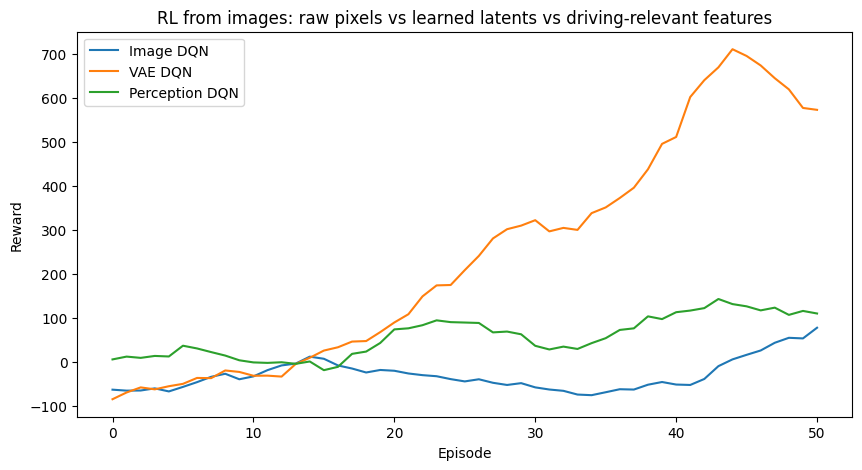

In [ ]:
# Compare learning curves: end-to-end image DQN vs VAE state vs perception state
plt.figure(figsize=(10, 5))
plt.plot(moving_average(episode_rewards_image_dqn), label='Image DQN')
plt.plot(moving_average(episode_rewards_vae_dqn), label='VAE DQN')
plt.plot(moving_average(episode_rewards_perception_dqn), label='Perception DQN')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.title('RL from images: raw pixels vs learned latents vs driving-relevant features')
plt.show()


In [ ]:
## Solution
# Visualize ray-cast state during one evaluation episode
STATE_NAMES = [f'fwd {i}' for i in range(NUM_FORWARD_RAYS)] + ['left', 'right'] + ['speed', 'steering', 'gyro']

max_steps = max_steps_per_episode
frames = np.empty((max_steps, *env.observation_space.shape), dtype=np.uint8)
overlays = np.empty_like(frames)
states = np.empty((max_steps, perception_dqn_agent.state_dim), dtype=np.float32)

state = env.reset()[0]
reward_sum = 0.0
done = False
step = 0
while not done and step < max_steps:
	frames[step] = state
	states[step] = perception_dqn_agent.encoder.encode(state).cpu().numpy()
	overlays[step] = render_perception_overlay(state)
	action = perception_dqn_agent.act(state, explore=False)
	state, reward, done, truncated, _ = env.step(action)
	reward_sum += float(reward)
	done = done or truncated
	step += 1

frames, overlays, states = frames[:step], overlays[:step], states[:step]
print(f'Total reward for the episode: {reward_sum}')

video_frames = []
for i in range(len(frames)):
	fig, axes = plt.subplots(1, 3, figsize=(12, 4))
	axes[0].imshow(frames[i]); axes[0].set_title('Environment'); axes[0].axis('off')
	axes[1].imshow(overlays[i]); axes[1].set_title('Radial rays'); axes[1].axis('off')
	axes[2].bar(np.arange(states.shape[1]), states[i])
	axes[2].set_xticks(np.arange(states.shape[1]))
	axes[2].set_xticklabels(STATE_NAMES, rotation=75, ha='right', fontsize=7)
	axes[2].set_ylim(-1, 1); axes[2].set_title('State vector')
	axes[2].axhline(0, color='gray', linewidth=0.5)
	plt.tight_layout(); fig.canvas.draw()
	img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(fig.canvas.get_width_height()[::-1] + (4,))[..., :3]
	video_frames.append(img); plt.close(fig)
media.show_video(video_frames, fps=100, loop=False)


Total reward for the episode: 160.86956521739583


This browser does not support the video tag.


### Tasks:
1. Implement CarRacingStateEncoder to transform the high-dimensional image input into a low-dimensional driving-relevant state. Which approach converges faster — end-to-end image DQN, VAE latents, or hand-crafted.
2. Discuss pros and cons of using low dimensional latent states from VAEs versus extracting dense state representations from first principles.
